# Plot benchmark results (gata / gatav)

Walks every result file matched by `DATA_GLOB` and, for each one, draws an
ata plot, an atav plot, and prints the best-parameter tables.

Each input file is a combined output from running both `gata_example` and
`gatav_example` in the same job. Lines are dispatched to the ata or atav
bucket based on which `MPI_Alltoall(v)` (or `gata` / `gatav`) tag was last
seen.

**Aggregation across the 30 repetitions of each `(tag, n, params)`:**
1. **Outlier removal** — Tukey 1.5×IQR fence.
2. **Center** — median of the 30 runs.
3. **Error bars** — `[min, max]` of the surviving samples (asymmetric).

**Across parameters at the same `n`:** pick the params (`b` for
`MPICH-scattered`, `(b, r)` for `gata`/`gatav`) with the smallest median.

In [ ]:
import glob
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt

# All result files matching this glob are processed (one plot pair per file).
# Path is relative to this notebook in plots/.
DATA_GLOB = '../data/*.sh.o*'

# Matches:  [tag] nprocs, n, extra1, extra2, time
LINE_RE = re.compile(
    r'\[([^\]]+)\]\s+(\d+),\s+(\d+),\s+(\d+),\s+(\d+),\s+([\d.eE+-]+)'
)

ATA_TAGS  = ['MPI_Alltoall',  'OMPI-linear', 'OMPI-pairwise',
             'MPICH-scattered', 'Spreadout', 'Bruck', 'gata']
ATAV_TAGS = ['MPI_Alltoallv', 'OMPI-linear', 'OMPI-pairwise',
             'MPICH-scattered', 'Spreadout', 'Bruck', 'gatav']

# Display labels for the legend. Keys are raw tags from the log; values are
# the human-readable names shown in the plot. Tags not listed render as-is.
TAG_LABELS = {
    'OMPI-linear':     'Basic linear',
    'OMPI-pairwise':   'Pairwise',
    'MPICH-scattered': 'scattered',
    'Bruck':           'Classic Bruck',
    'gata':            'GAta',
    'gatav':           'GAtav',
}

# Per-tag minimum n for plotting (drop warm-up-dominated small-n points).
MIN_N_PER_TAG = {
    'OMPI-linear': 64,
}

# Per-tag maximum n for plotting (drop congestion-dominated large-n points).
MAX_N_PER_TAG = {
    'Bruck': 512,
}

# Manual per-(variant, tag, nprocs, n) blacklist for one-off oddities.
BAD_POINTS = set()

# Auto-filter: for the watched tags, drop any point whose median is more than
# AUTO_BAD_RATIO times the chosen REFERENCE of the OTHER algorithms at the
# same (variant, nprocs, n).
#   AUTO_BAD_REF = 'min'    → drop if > ratio × fastest competitor (aggressive)
#   AUTO_BAD_REF = 'median' → drop if > ratio × median competitor (gentle)
AUTO_BAD_TAGS  = {'OMPI-linear'}
AUTO_BAD_REF   = 'min'
AUTO_BAD_RATIO = 2.0

# Each element is a `long long` (8 bytes), so block size in bytes = n * 8.
BYTES_PER_ELEM = 8


In [12]:
import statistics  # used by robust_stats / best_per_n


def parse_combined(path):
    """Read a combined log; return (ata_data, atav_data, nprocs_seen).

    The 'section' (ata vs atav) is tracked by which MPI/gata tag has been
    seen most recently. Shared tags (OMPI-*, MPICH-scattered, Spreadout,
    Bruck) inherit the current section.
    """
    def make_store():
        return defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

    ata, atav = make_store(), make_store()
    nprocs_seen = set()
    section = 'ata'

    with open(path) as f:
        for line in f:
            m = LINE_RE.search(line)
            if not m:
                continue
            tag, nprocs, n, e1, e2, t = m.groups()
            if tag in ('MPI_Alltoall', 'gata'):
                section = 'ata'
            elif tag in ('MPI_Alltoallv', 'gatav'):
                section = 'atav'
            store = ata if section == 'ata' else atav
            nprocs_seen.add(int(nprocs))
            store[tag][int(n)][(int(e1), int(e2))].append(float(t))
    return ata, atav, nprocs_seen


def robust_stats(times):
    """Median + low/high bounds after dropping outliers via Tukey 1.5-IQR fence.

    Returns (median, lo, hi) where median is over all original samples,
    and (lo, hi) are min/max of values that fall inside
    [Q1 - 1.5*IQR, Q3 + 1.5*IQR]. With fewer than 4 samples we just
    return min/max of the raw data.
    """
    sorted_t = sorted(times)
    med = statistics.median(sorted_t)
    if len(sorted_t) < 4:
        return med, sorted_t[0], sorted_t[-1]
    q1, _, q3 = statistics.quantiles(sorted_t, n=4)
    iqr = q3 - q1
    lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    filtered = [t for t in sorted_t if lo_fence <= t <= hi_fence]
    if not filtered:
        filtered = sorted_t
    return med, min(filtered), max(filtered)


def best_per_n(data_for_tag):
    """{n: ((e1, e2), median, lo, hi)}.

    Step 1: for each (n, params) reduce the 30 reps to (median, lo, hi)
            using Tukey 1.5-IQR outlier trimming.
    Step 2: for each n, pick the params with the smallest median.
    """
    result = {}
    for n, params in data_for_tag.items():
        best = None  # (params, med, lo, hi)
        for p, times in params.items():
            med, lo, hi = robust_stats(times)
            if best is None or med < best[1]:
                best = (p, med, lo, hi)
        result[n] = best
    return result

In [ ]:
import statistics
import math
from matplotlib.ticker import ScalarFormatter, LogLocator, NullFormatter


def tuned_bruck_per_n(data, nprocs, our_tag):
    """Synthesise a 'Tuned Bruck' curve from the gata/gatav sweep.

    Picks the (b=1, r ~= sqrt(P)) configuration --- i.e. classical
    radix-r Bruck without batching, at the textbook optimal radix.
    Returns {n: (median, lo, hi)} or {} if our_tag absent / no b=1
    configurations are present.
    """
    if our_tag not in data:
        return {}
    target = math.sqrt(nprocs)
    # Discover the r values that appear with b=1 in the sweep
    rs_with_b1 = set()
    for n, params in data[our_tag].items():
        for (b, r) in params.keys():
            if b == 1:
                rs_with_b1.add(r)
    if not rs_with_b1:
        return {}
    near_r = min(rs_with_b1, key=lambda r: abs(r - target))
    result = {}
    for n, params in data[our_tag].items():
        if (1, near_r) in params:
            med, lo, hi = robust_stats(params[(1, near_r)])
            result[n] = (med, lo, hi)
    return result


def _fmt_xtick(n):
    """Format the x-axis tick label.

    Bytes (n * BYTES_PER_ELEM) shown verbatim up to 512; anything larger
    becomes ``<x>k`` with x = bytes / 1024.  This keeps every label at
    most three characters wide (e.g. 1k, 2k, 64k) and avoids the
    overlap that arises with four-digit labels at large fonts.
    """
    b = n * BYTES_PER_ELEM
    if b > 512:
        return f'{b // 1024}k'
    return str(b)


def plot(data, variant, nprocs, save_to=None):
    tags = ATAV_TAGS if variant == 'atav' else ATA_TAGS
    ours = 'gatav' if variant == 'atav' else 'gata'

    # Slightly larger canvas to keep big fonts inside the frame.
    fig, ax = plt.subplots(figsize=(14, 9))
    colors  = ['#888888', '#1f77b4', '#2ca02c', '#9467bd',
               '#8c564b', '#17becf', '#d62728']
    TUNED_BRUCK_COLOR = '#ff7f0e'  # orange, distinct from the 7-tag palette

    # Pre-compute best_per_n for every present tag (used twice).
    bests = {tag: best_per_n(data[tag]) for tag in tags if tag in data}

    # Auto-detect "way-too-slow" points for the watched tags.
    reducer = min if AUTO_BAD_REF == 'min' else statistics.median
    auto_bad = set()
    for watched in AUTO_BAD_TAGS:
        if watched not in bests:
            continue
        for n, (_, my_med, _, _) in bests[watched].items():
            others = []
            for t, b in bests.items():
                if t == watched:
                    continue
                if (variant, t, nprocs, n) in BAD_POINTS:
                    continue
                if n in b:
                    others.append(b[n][1])
            if not others:
                continue
            ref = reducer(others)
            if my_med > AUTO_BAD_RATIO * ref:
                auto_bad.add((watched, n))
    if auto_bad:
        print(f'[{variant} {nprocs}p] auto-dropped (ref={AUTO_BAD_REF}, '
              f'ratio>{AUTO_BAD_RATIO}): '
              + ', '.join(f'{t}@n={n}' for t, n in sorted(auto_bad)))

    all_ns = set()
    for i, tag in enumerate(tags):
        if tag not in data:
            continue
        best = bests[tag]
        min_n = MIN_N_PER_TAG.get(tag, 0)
        max_n = MAX_N_PER_TAG.get(tag, float('inf'))
        ns = sorted(n for n in best.keys()
                    if min_n <= n <= max_n
                    and (variant, tag, nprocs, n) not in BAD_POINTS
                    and (tag, n) not in auto_bad)
        if not ns:
            continue
        all_ns.update(ns)
        meds = [best[n][1] * 1000 for n in ns]
        los  = [best[n][2] * 1000 for n in ns]
        his  = [best[n][3] * 1000 for n in ns]
        yerr = [[m - l for m, l in zip(meds, los)],
                [h - m for h, m in zip(his, meds)]]
        is_ours = (tag == ours)
        label = TAG_LABELS.get(tag, tag)
        ax.errorbar(ns, meds, yerr=yerr,
                    marker='o',
                    color=colors[i % len(colors)],
                    label=label,
                    linewidth=4 if is_ours else 2,
                    markersize=14 if is_ours else 10,
                    capsize=6,
                    capthick=2 if is_ours else 1.5,
                    elinewidth=2 if is_ours else 1.5,
                    zorder=10 if is_ours else 1)

    # --- Tuned Bruck overlay: (b=1, r ≈ sqrt(P)) from gata/gatav data ---
    tb = tuned_bruck_per_n(data, nprocs, ours)
    if tb:
        tb_ns = sorted(n for n in tb.keys() if n in all_ns or all_ns == set())
        if tb_ns:
            tb_meds = [tb[n][0] * 1000 for n in tb_ns]
            tb_los  = [tb[n][1] * 1000 for n in tb_ns]
            tb_his  = [tb[n][2] * 1000 for n in tb_ns]
            tb_yerr = [[m - l for m, l in zip(tb_meds, tb_los)],
                       [h - m for h, m in zip(tb_his, tb_meds)]]
            ax.errorbar(tb_ns, tb_meds, yerr=tb_yerr,
                        marker='o',
                        color=TUNED_BRUCK_COLOR,
                        label='Tuned Bruck',
                        linewidth=2, markersize=10,
                        capsize=6, capthick=1.5, elinewidth=1.5,
                        zorder=2)
            all_ns.update(tb_ns)

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')

    sorted_ns = sorted(all_ns)
    ax.set_xticks(sorted_ns)
    ax.set_xticklabels([_fmt_xtick(n) for n in sorted_ns])
    ax.xaxis.set_minor_locator(plt.NullLocator())

    y_formatter = ScalarFormatter()
    y_formatter.set_scientific(False)
    y_formatter.set_useOffset(False)
    ax.yaxis.set_major_locator(LogLocator(base=10, numticks=12))
    ax.yaxis.set_minor_locator(LogLocator(base=10, subs=[2.0, 5.0], numticks=24))
    ax.yaxis.set_major_formatter(y_formatter)
    ax.yaxis.set_minor_formatter(y_formatter)

    # Bump tick label sizes as large as we can without overlapping the
    # canvas; major y ticks especially because we have ~5 decades.
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.tick_params(axis='y', which='minor', labelsize=22)

    xlabel = ('Maximum data-block size (bytes)' if variant == 'atav'
              else 'Data-block size (bytes)')
    ax.set_xlabel(xlabel, fontsize=32, fontweight='bold')
    ax.set_ylabel('Time (ms, log scale)', fontsize=32, fontweight='bold')
    ax.grid(True, which='both', linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=24)
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_to}')
    plt.show()


def print_best_table(data, tag, param_names):
    """param_names = ('b',) or ('b', 'r')."""
    if tag not in data:
        print(f'(no data for {tag})')
        return
    cols = ['n'] + list(param_names) + ['median(ms)', 'lo(ms)', 'hi(ms)']
    widths = [10] + [6] * len(param_names) + [13, 13, 13]
    header = '  '.join(f'{c:>{w}}' for c, w in zip(cols, widths))
    print(f'Best {tag} parameters per n (median after Tukey 1.5-IQR trim, ms):')
    print(header)
    print('-' * len(header))
    best = best_per_n(data[tag])
    for n in sorted(best.keys()):
        (e1, e2), med, lo, hi = best[n]
        med, lo, hi = med * 1000, lo * 1000, hi * 1000
        if len(param_names) == 1:
            row_vals = [n, e1, med, lo, hi]
        else:
            row_vals = [n, e1, e2, med, lo, hi]
        row = '  '.join(
            (f'{v:>{w}}' if not isinstance(v, float) else f'{v:>{w}.6g}')
            for v, w in zip(row_vals, widths))
        print(row)


Found 6 result file(s):
  run_256_merged.sh.o
  run_512_merged.sh.o
  run_1024_merged.sh.o
  run_2048_merged.sh.o
  run_4096_merged.sh.o
  run_8192_merged.sh.o

FILE: run_256_merged.sh.o

--- ata, 256 processes ---
[ata 256p] auto-dropped (ref=min, ratio>2.0): OMPI-linear@n=2, OMPI-linear@n=4, OMPI-linear@n=8, OMPI-linear@n=16, OMPI-linear@n=32, OMPI-linear@n=256, OMPI-linear@n=512, OMPI-linear@n=1024, OMPI-linear@n=2048
Saved: gata_256.png


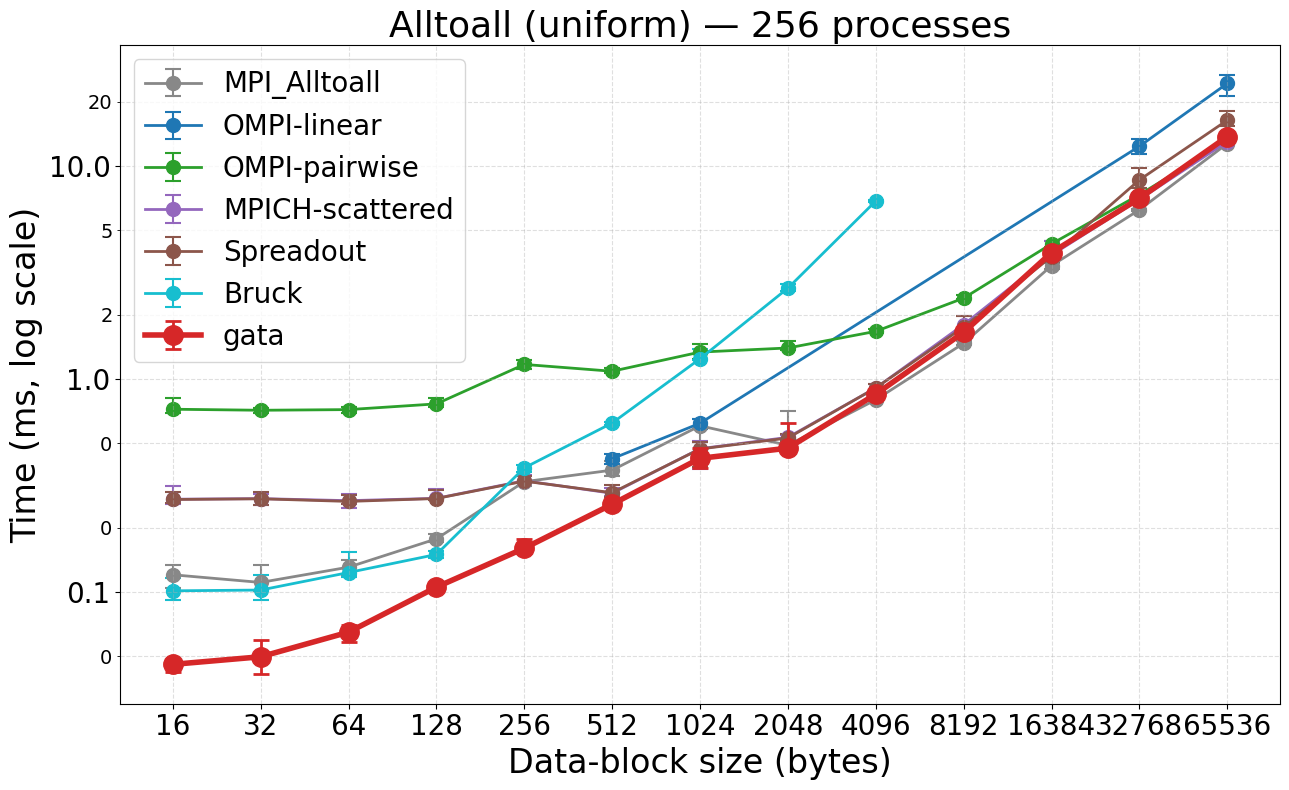

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     256        0.27252       0.260019       0.313448
         4     256       0.274349       0.256876       0.286857
         8     256       0.268311       0.246901       0.289612
        16     256        0.27514       0.269588        0.30417
        32     256       0.332724       0.327695       0.354675
        64     256       0.290639       0.282057       0.306402
       128     256       0.470526       0.379739       0.511589
       256     256       0.531873       0.514964       0.546093
       512     256       0.907234        0.87958       0.946895
      1024     256        1.79897        1.70676        1.97656
      2048     256        3.81737        3.55165        4.44138
      4096       2        6.96071        6.93641        6.99458
      8192       1        1

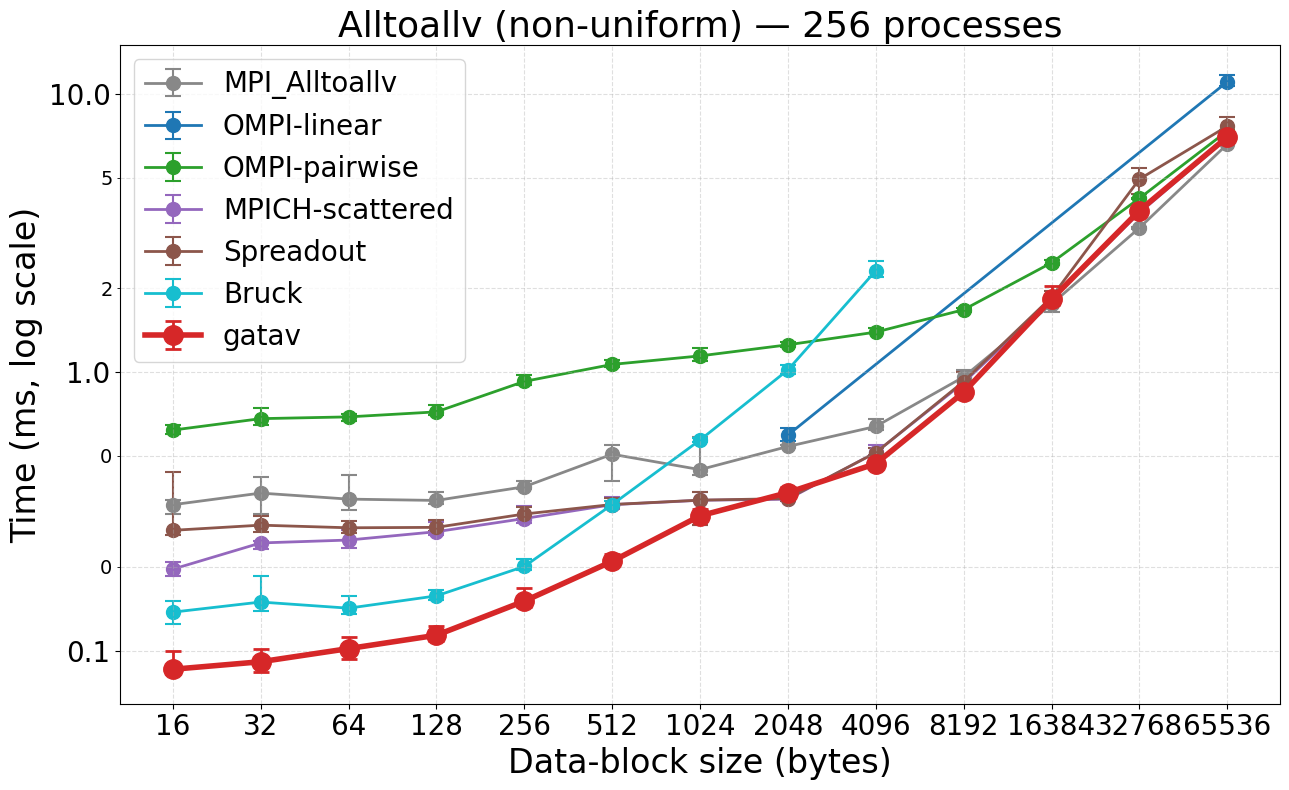

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     256       0.195967       0.185087       0.208842
         4     256       0.243497       0.231895       0.247657
         8     256       0.249417       0.234318       0.270357
        16     256       0.267248       0.259531       0.290051
        32     256       0.298013       0.287188        0.33101
        64     256       0.334247       0.322457        0.35661
       128     256       0.346658        0.28302       0.372399
       256     256       0.349706       0.344115       0.357109
       512     256        0.51471       0.501921       0.546614
      1024     128       0.917415       0.872003        1.00287
      2048      64        1.82799        1.78125        1.89413
      4096       4          3.738        3.67792        3.77866
      8192       2        6

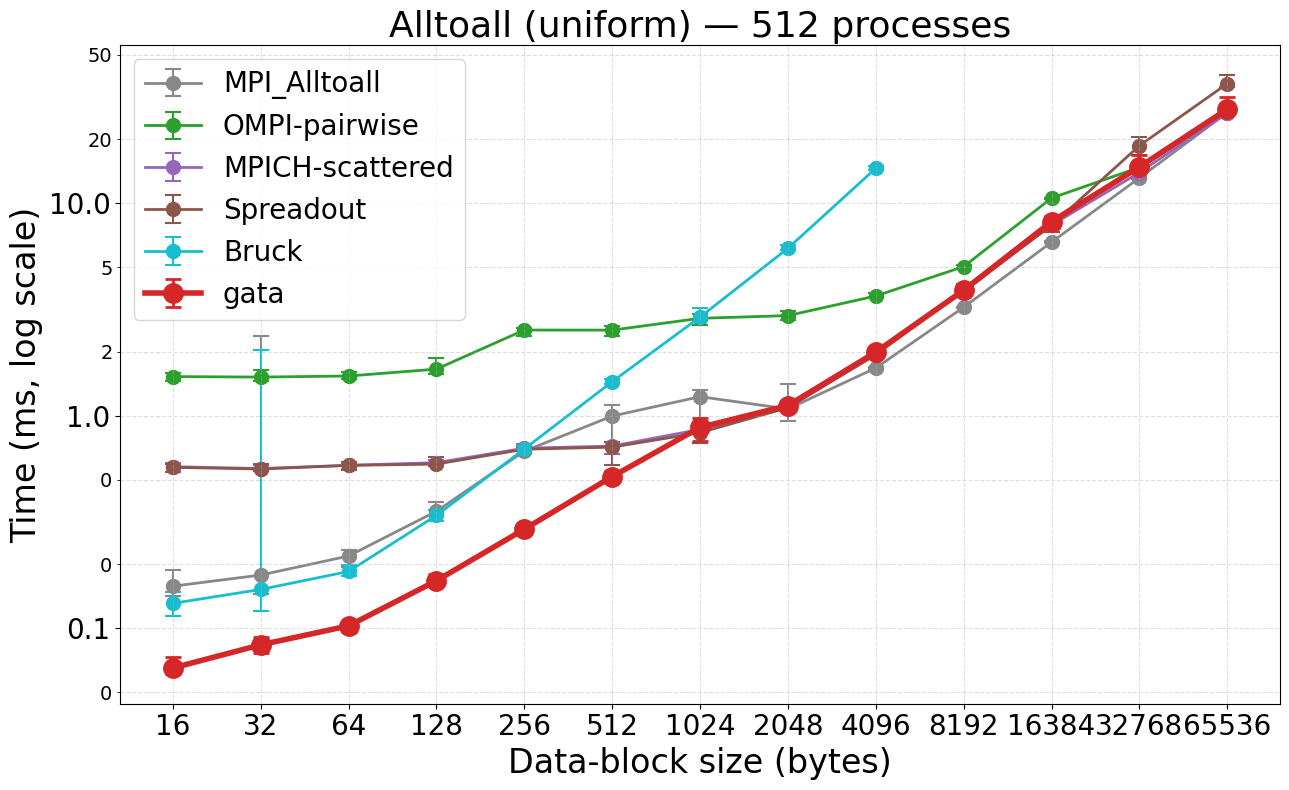

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     512       0.575363       0.545528       0.598642
         4     512       0.564071       0.548391       0.587162
         8     512       0.583884       0.559356       0.599353
        16     512       0.601142       0.579215       0.621745
        32     512       0.702813       0.683751       0.735568
        64     512       0.719681       0.657693       0.749844
       128     512       0.861486       0.744205       0.906675
       256     512        1.08774        1.07013        1.10154
       512     512        1.96792        1.91448        2.09264
      1024     512        3.82989        3.63457        4.10531
      2048     512        7.87265        7.35192        8.40642
      4096       2        13.9202        13.8466        14.1362
      8192       1        2

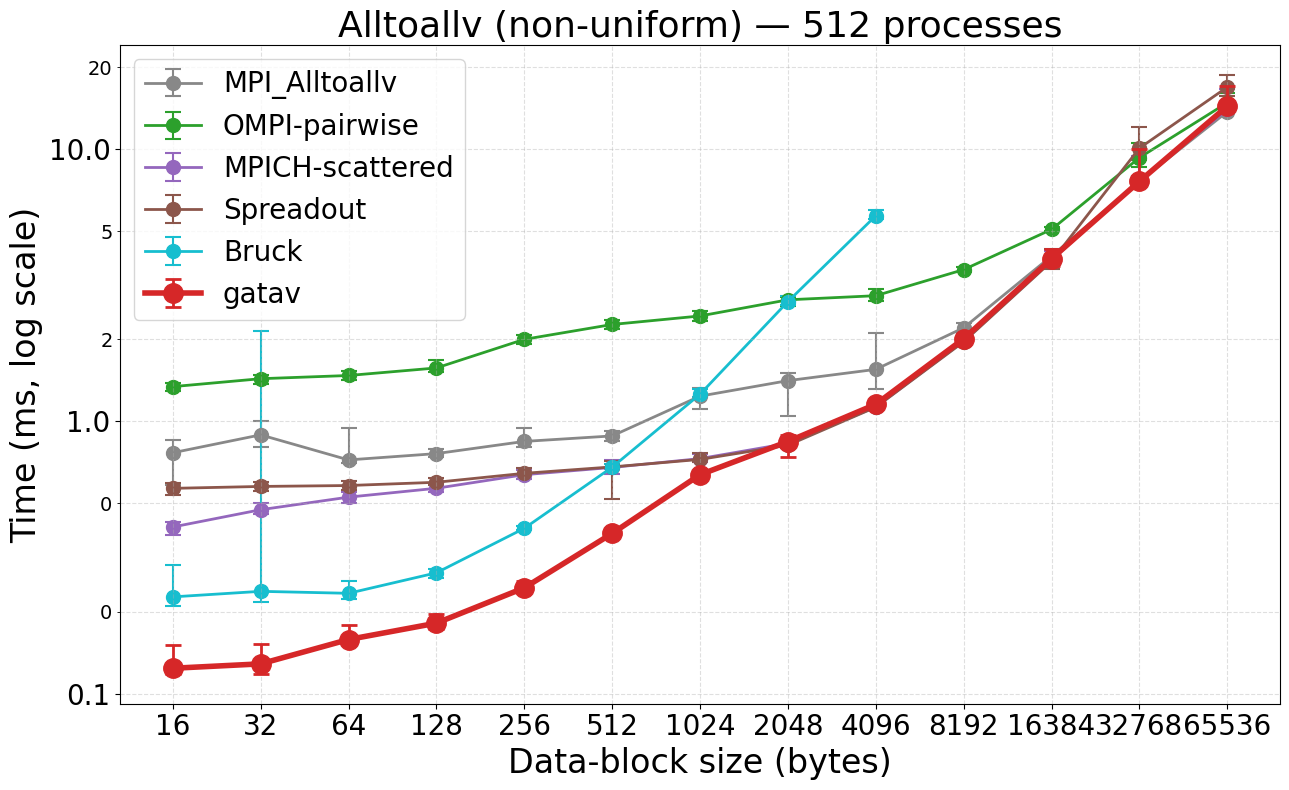

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2     512       0.409192       0.382997       0.426937
         4     512       0.473611       0.456235       0.500551
         8     512       0.526828        0.50055       0.549831
        16     512       0.567852        0.54934       0.586789
        32     512        0.63695       0.613902       0.664976
        64     512       0.677352       0.640811       0.720098
       128     512       0.729863       0.706581       0.760974
       256     512       0.830199       0.811621       0.867352
       512     256        1.12933        1.11566        1.16103
      1024     512        1.97246        1.92434        2.09078
      2048     512        3.90444        3.78145        4.22486
      4096       4        7.68216         7.6036        9.46262
      8192       2        1

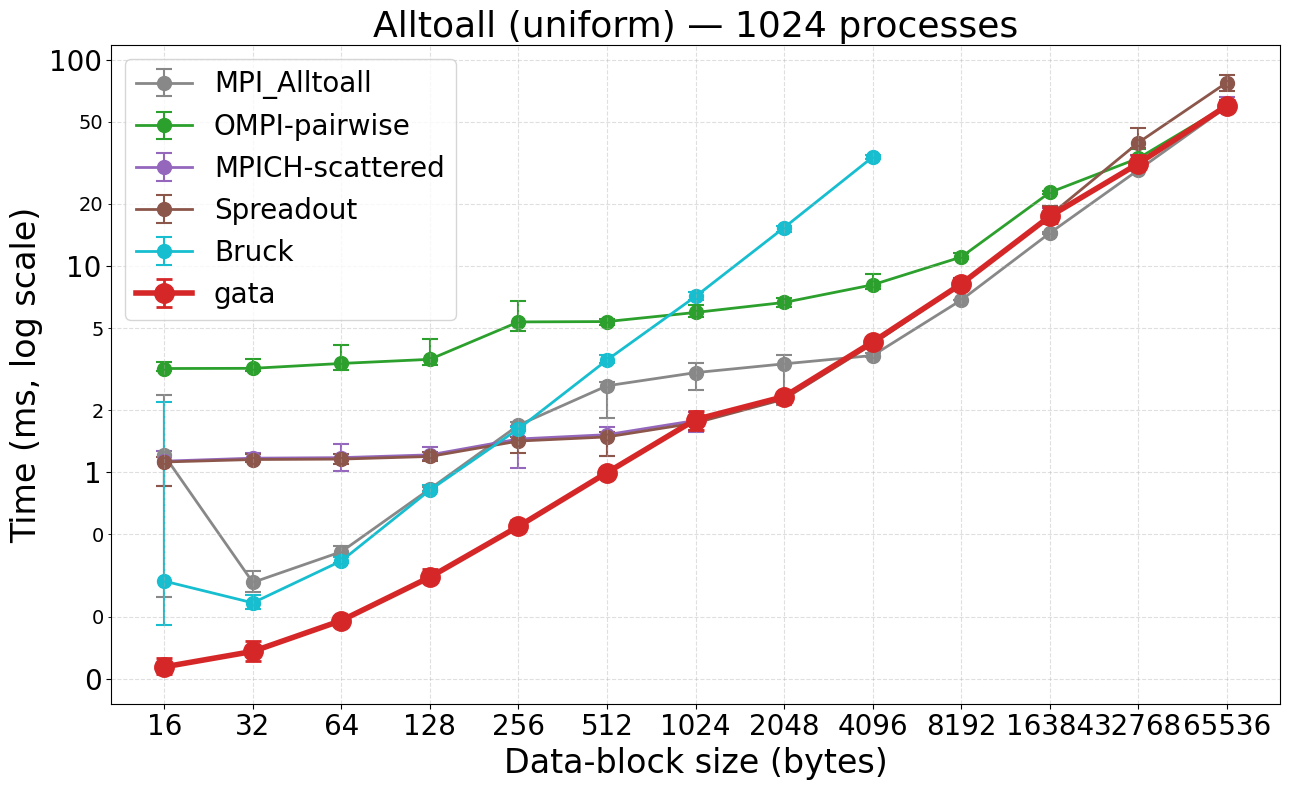

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    1024        1.13288       0.857069        1.27366
         4    1024        1.17128        1.14192        1.23671
         8    1024        1.17819        1.01789        1.37623
        16    1024        1.21538        1.15317        1.32372
        32    1024        1.45074        1.05258        1.67312
        64    1024        1.52213        1.19963        1.65778
       128     512        1.78348        1.57082         1.9579
       256     512        2.29949        2.25568        2.36278
       512     512        4.21845        4.15126        4.42028
      1024    1024        8.12153        7.80708        8.61472
      2048    1024        17.3606        16.0427        19.0419
      4096       2        31.6543        29.6834        34.5979
      8192       1        5

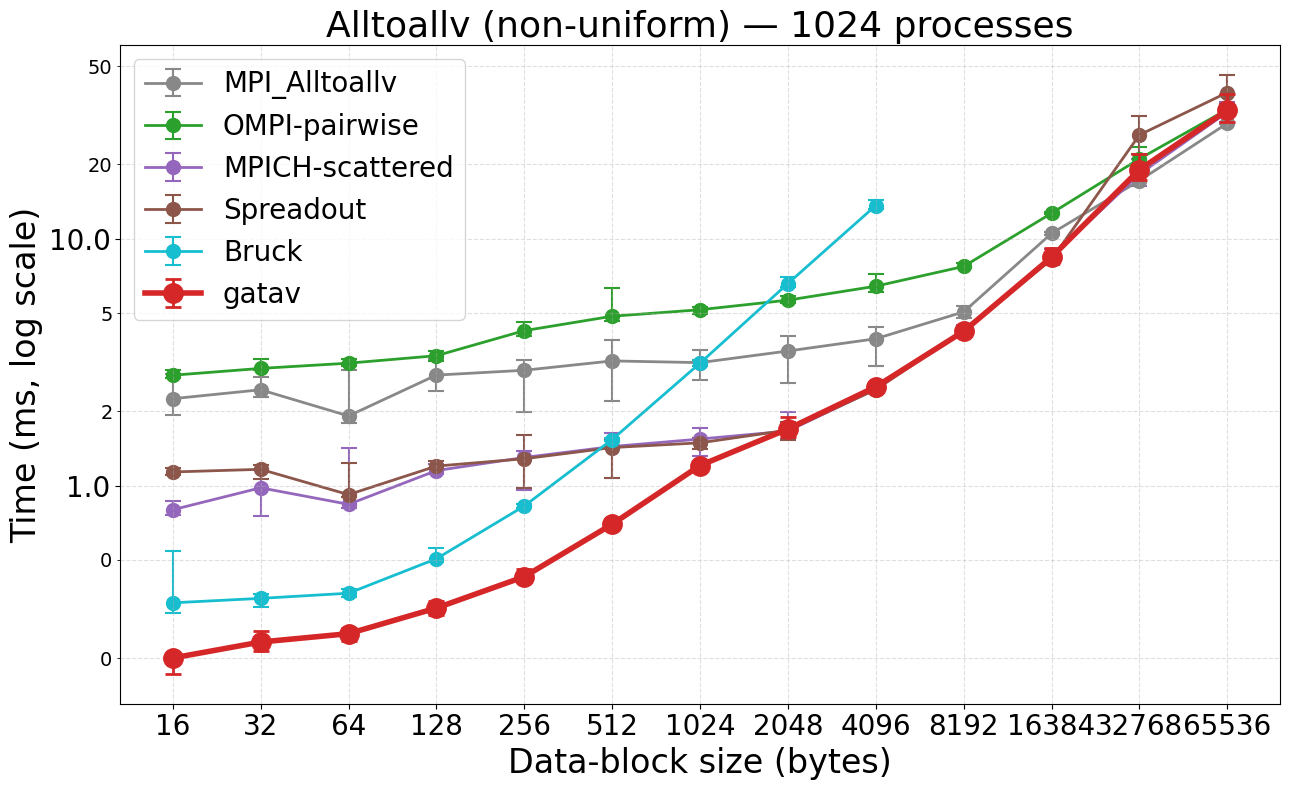

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    1024       0.797807       0.756313       0.869595
         4    1024       0.979067       0.755188        1.15457
         8     256       0.839286       0.810962        1.42355
        16    1024        1.14955        1.11636        1.22054
        32    1024        1.29937       0.961877        1.38222
        64    1024         1.4389        1.07332        1.62923
       128     512          1.543        1.31249        1.71415
       256     256         1.6626        1.53877        1.97995
       512     512         2.4611         2.4199        2.51642
      1024     512        4.23198        4.13429        4.45207
      2048    1024        8.43375        8.06887        9.09825
      4096       4         18.269        16.3129        21.0708
      8192       2        3

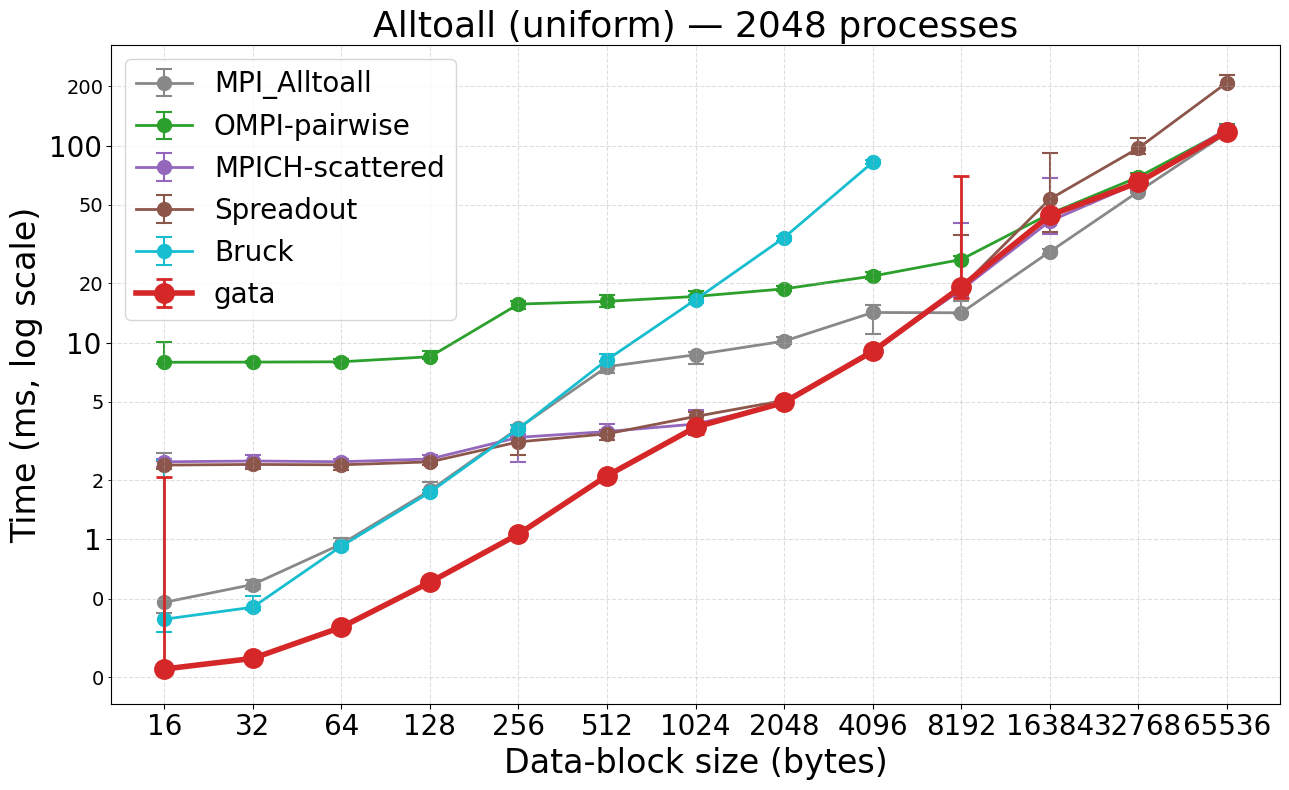

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    2048        2.47912        2.34557        2.57099
         4    2048        2.50218        2.34602        2.68285
         8    2048        2.48077        2.32691        2.56014
        16    2048        2.56159        2.46621        2.67744
        32    2048        3.29989        2.47676        3.44215
        64      32          3.532        3.35404        3.83726
       128     512         3.8552        3.37865        4.54478
       256     128        4.91063        4.85996        5.00605
       512    1024        9.08249        8.77048        9.47805
      1024    2048        18.5199        17.0216        40.5401
      2048    2048        41.3558         35.775        68.3939
      4096       2        64.7585        58.5503        68.8946
      8192       1        1

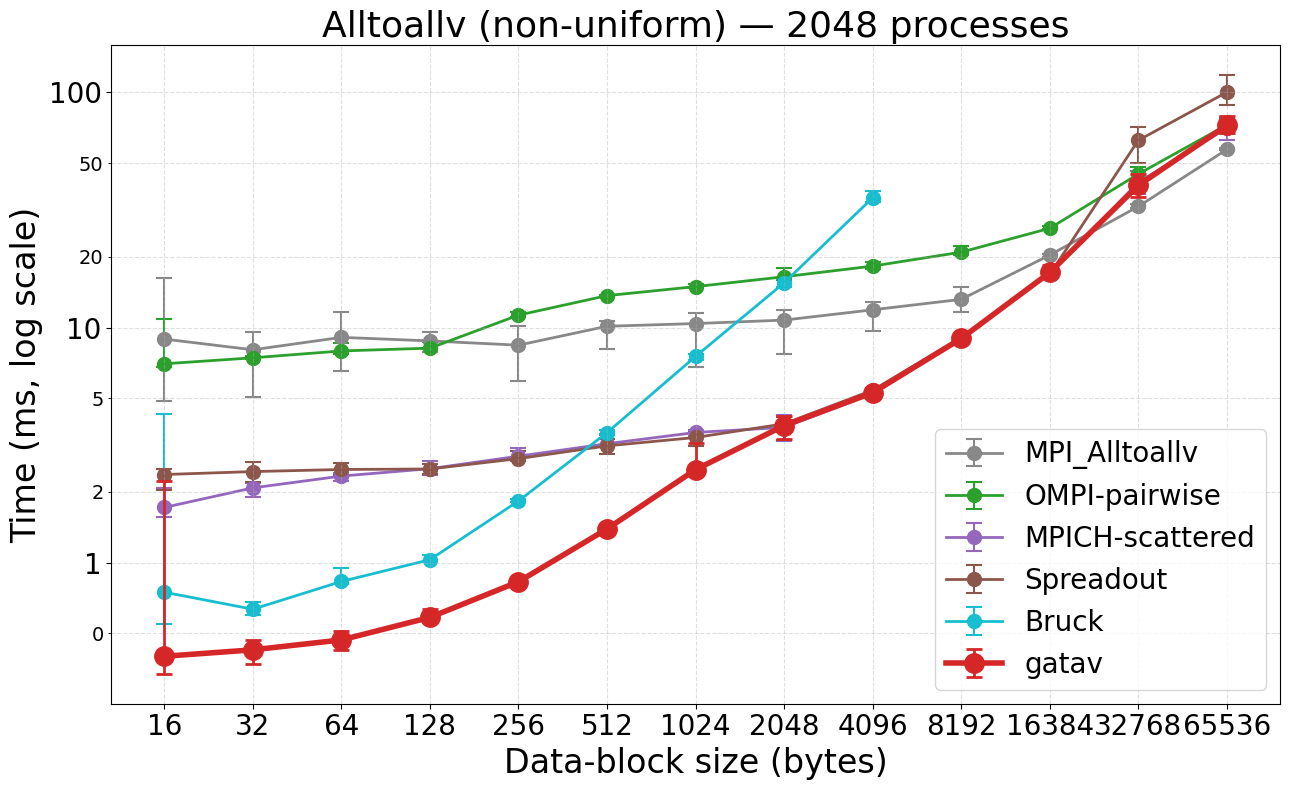

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2    2048        1.71762        1.56669        2.07599
         4    2048         2.0804        1.90317        2.17724
         8    2048         2.3357        2.23531        2.41536
        16    2048        2.51033         2.3672        2.70604
        32    2048        2.83761        2.72623        3.05987
        64    2048        3.20656        3.10599        3.50825
       128    2048         3.5791        3.44284        3.67695
       256     512        3.76328        3.30097        4.24112
       512     256        5.23242        5.16806        5.31036
      1024    1024        9.05037        8.87047        9.34248
      2048    2048        17.0123        16.5004        17.7514
      4096       4        41.4564        36.9702        46.2217
      8192       2        7

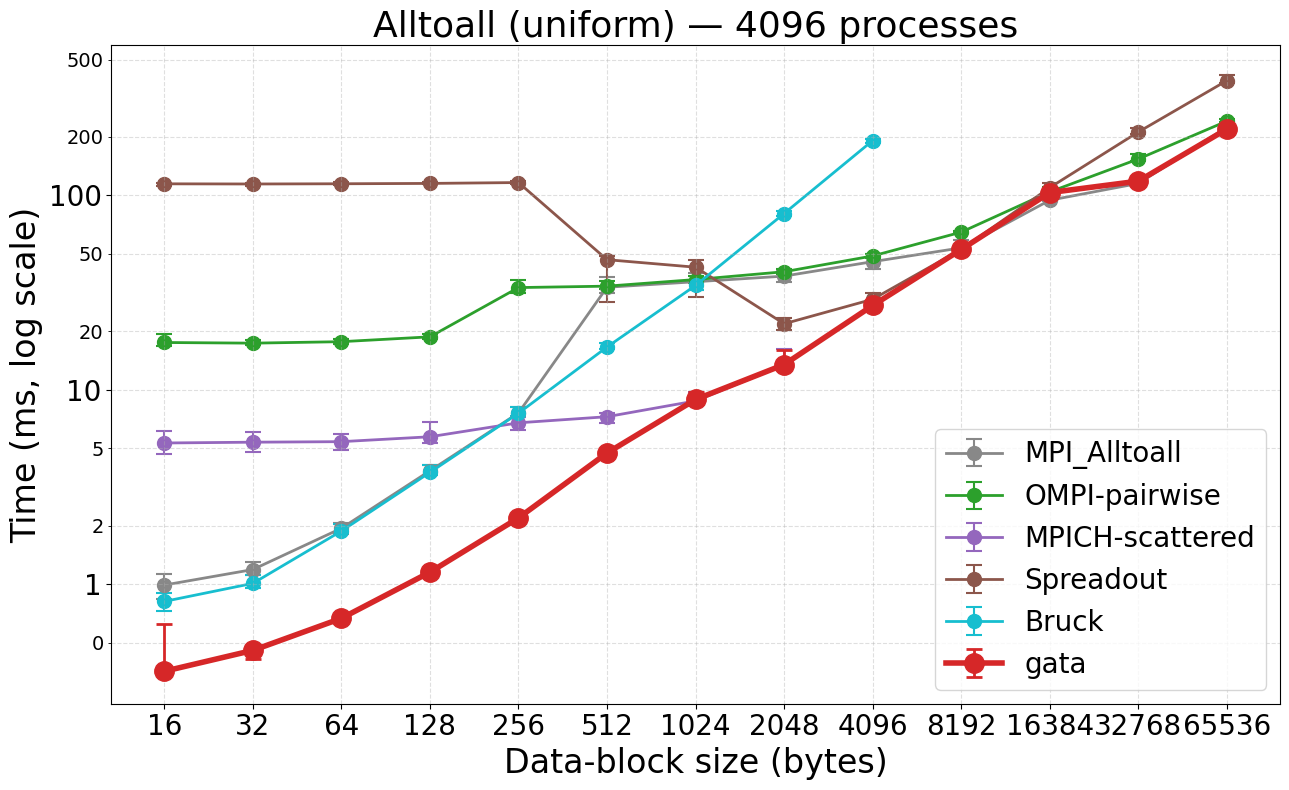

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2      32        5.32076        4.66637        6.13348
         4      32        5.37098        4.78649        6.09416
         8      32        5.40514        4.88478        5.88569
        16      32        5.72804        5.28896        6.79585
        32      32         6.7576        6.19657        7.24108
        64      32        7.26393        6.76496        7.55339
       128      64        8.76029        8.23414        9.73085
       256     256        13.4167        12.8947        16.2559
       512    1024        27.1264         26.569        28.1403
      1024    4096        52.5532        51.2984        53.9674
      2048       1        103.134        102.247        105.892
      4096       8        116.277        114.619        118.625
      8192       4        2

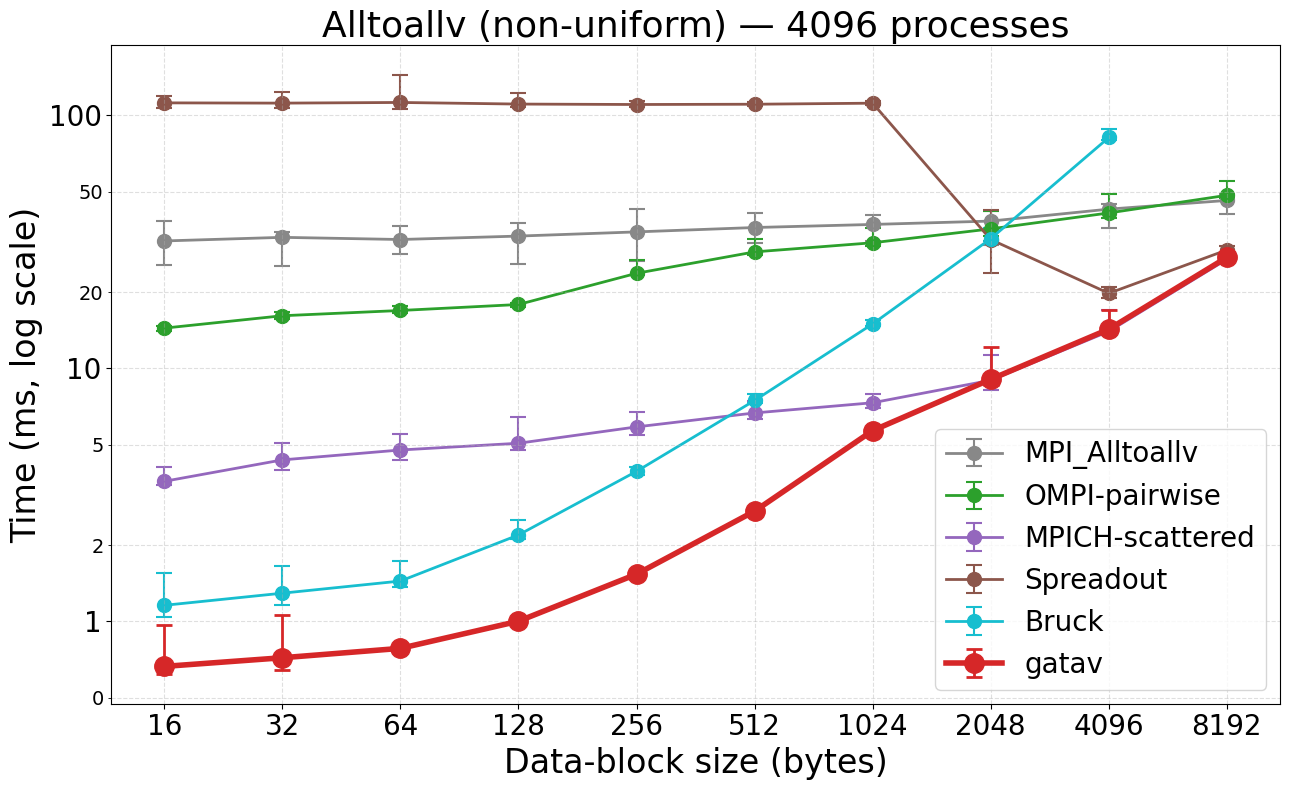

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2      64        3.57852        3.45188        4.06085
         4      32         4.3494        3.95303        5.08376
         8      32         4.7595        4.36422        5.48697
        16      32        5.06059         4.7542        6.39705
        32      32         5.8732        5.45823        6.75101
        64      32         6.6681        6.33587        7.43147
       128      32        7.31538        6.96842        7.89004
       256      64        8.97685        8.22436        11.2672
       512     256        14.0046        13.6093        16.9376
      1024    1024         26.989        26.2915        28.6507

Best gatav parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
---------------

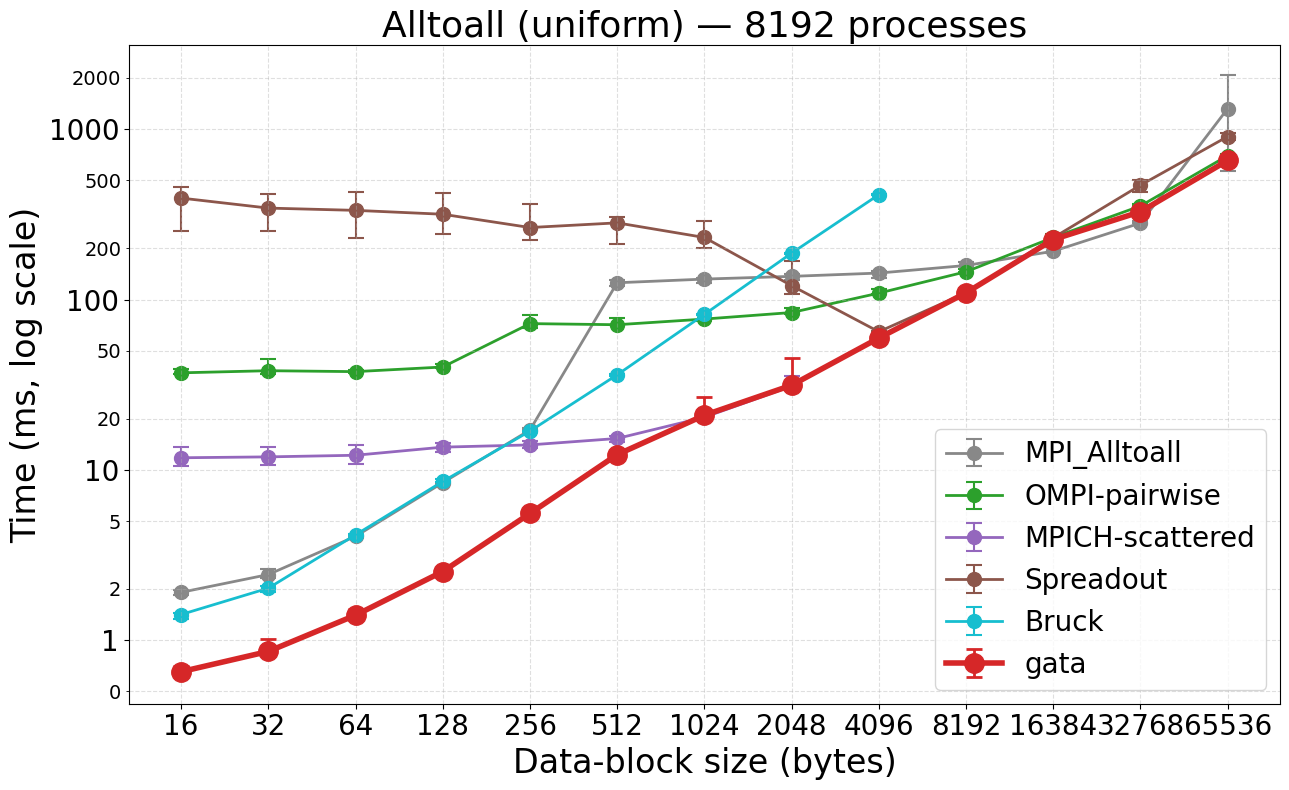

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2      32        11.7678        10.5826         13.602
         4      32        11.9103        10.6634        13.6723
         8      32        12.1745        10.8521         14.035
        16      32        13.5845        12.7767         14.318
        32      32        14.0044        13.3511        14.7005
        64      32        15.2747        14.6483        15.7764
       128      32        20.3494        19.5871         22.144
       256     512        31.0008        29.5588          35.74
       512    2048        59.5323        58.4787        61.9922
      1024    8192        109.681         108.51        112.153
      2048       2        224.382        223.471        226.538
      4096      16        327.392        326.278        327.662
      8192      16        6

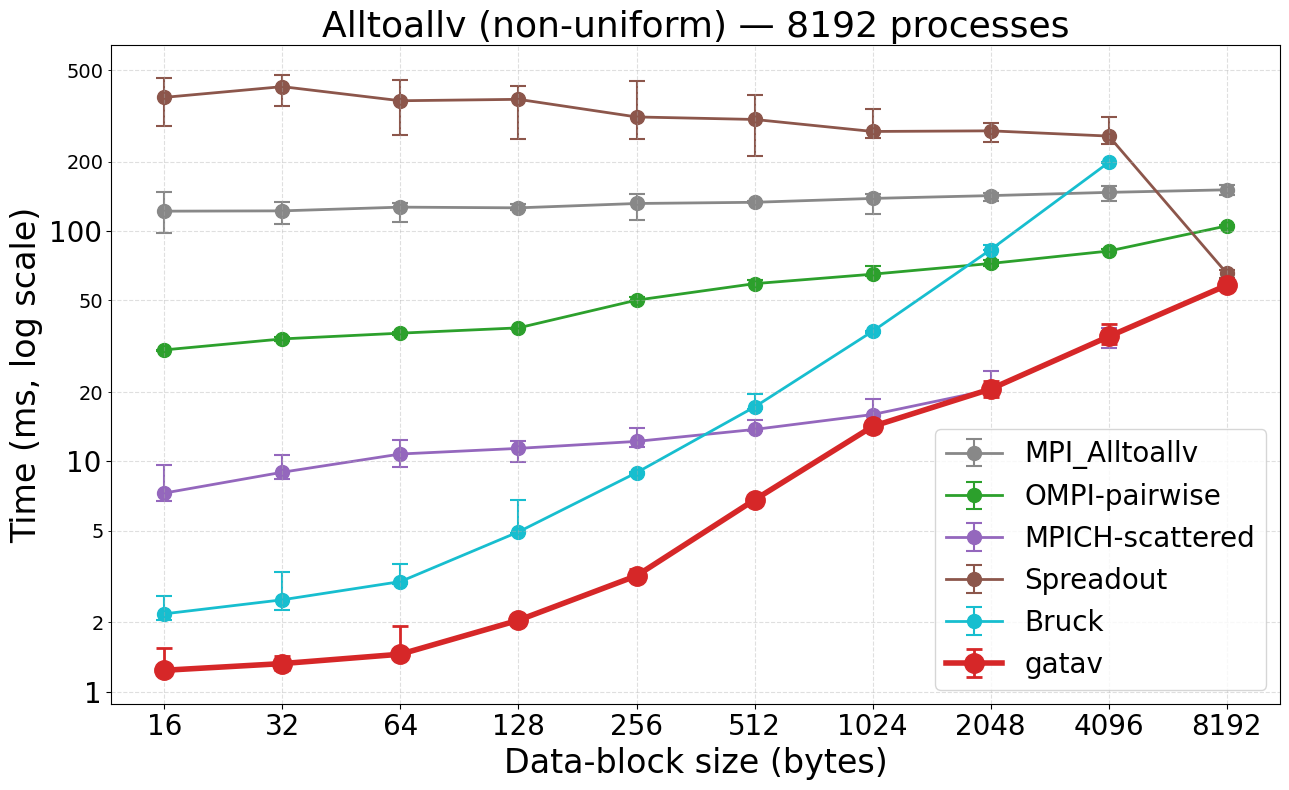

Best MPICH-scattered parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b     median(ms)         lo(ms)         hi(ms)
---------------------------------------------------------------
         2      64         7.2858        6.73101         9.6105
         4      32         8.9736        8.36151        10.6216
         8      32        10.7665        9.47537        12.4295
        16      32        11.3909        9.94986        12.2892
        32      32         12.213        11.5395        13.9067
        64      32        13.7643        13.5713        15.1543
       128      32        15.9769        14.7375        18.5815
       256      16        20.4569        19.7132        24.6855
       512     128        34.7523        31.0467        38.1008
      1024    1024        58.3373        57.0691        62.0856

Best gatav parameters per n (median after Tukey 1.5-IQR trim, ms):
         n       b       r     median(ms)         lo(ms)         hi(ms)
---------------

In [15]:
def _file_nprocs(path):
    """Extract nprocs from a 'run_<N>.sh.o<JOBID>' filename for sorting."""
    m = re.search(r'run_(\d+)', os.path.basename(path))
    return int(m.group(1)) if m else 0


files = sorted(glob.glob(DATA_GLOB), key=_file_nprocs)
print(f'Found {len(files)} result file(s):')
for f in files:
    print(f'  {os.path.basename(f)}')


def process_file(path):
    base = os.path.basename(path)
    print('\n' + '=' * 70)
    print(f'FILE: {base}')
    print('=' * 70)

    ata_data, atav_data, nprocs_seen = parse_combined(path)
    if not nprocs_seen:
        print('(no benchmark lines)'); return
    nprocs = next(iter(nprocs_seen))

    # ata
    print(f'\n--- ata, {nprocs} processes ---')
    plot(ata_data,  'ata',  nprocs, save_to=f'gata_{nprocs}.png')
    print_best_table(ata_data, 'MPICH-scattered', ('b',))
    print()
    print_best_table(ata_data, 'gata', ('b', 'r'))

    # atav
    print(f'\n--- atav, {nprocs} processes ---')
    plot(atav_data, 'atav', nprocs, save_to=f'gatav_{nprocs}.png')
    print_best_table(atav_data, 'MPICH-scattered', ('b',))
    print()
    print_best_table(atav_data, 'gatav', ('b', 'r'))


for f in files:
    process_file(f)